In [1]:
import os
import cv2

# Path to the directory containing the images
directory_path = r'C:\Users\USER\Desktop\DeepLearning Project End_to_End\images'

# Loop through all the files in the directory
for filename in os.listdir(directory_path):
    # Check if the file is an image file
    if filename.endswith('.jpg') or filename.endswith('.png') or filename.endswith('.bmp'):
        # Load the image
        img = cv2.imread(os.path.join(directory_path, filename))

        # Convert the image to grayscale
        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

        # Normalize the pixel values to range from 0 to 255
        normalized_gray = cv2.normalize(gray, None, 0, 255, cv2.NORM_MINMAX)

        # Save the normalized image
        cv2.imwrite(os.path.join(directory_path, 'normalized_' + filename), normalized_gray)


In [2]:
import tensorflow as tf
from tensorflow.keras import models,layers
import matplotlib.pyplot as plt

In [52]:
IMAGE_SIZE = 255
BATCH_SIZE = 32
EPOCHS = 50
CHANNELS = 3

# Import data into tensorflow dataset object
# We will use image_dataset_from_directory api to load all images in tensorflow dataset: https://www.tensorflow.org/api_docs/python/tf/keras/preprocessing/image_dataset_from_directory

In [53]:
dataset = tf.keras.preprocessing.image_dataset_from_directory(
"images",
shuffle=True,
image_size=(IMAGE_SIZE,IMAGE_SIZE),
    
batch_size= BATCH_SIZE
)

Found 1195 files belonging to 4 classes.


In [54]:
class_names =dataset.class_names
class_names

['180', '240', '320', '400']

In [55]:
len(dataset)

38

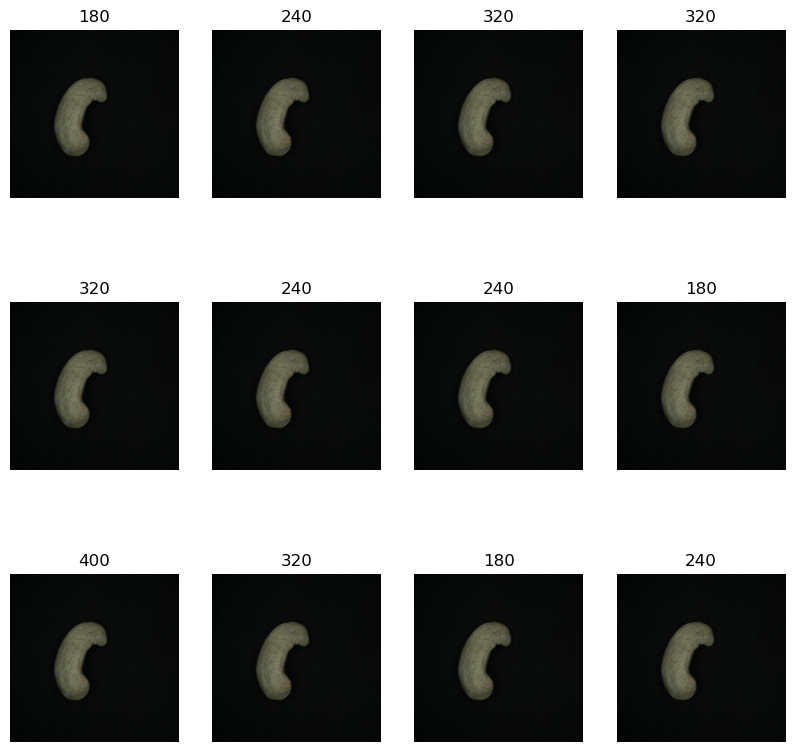

In [57]:
plt.figure(figsize=(10,10))
for image_batch,label_batch in dataset.take(1):
    for i in range(12):
        ax = plt.subplot(3,4,i+1)
        plt.imshow(image_batch[0].numpy().astype("uint8"))
        # As we dont want number in images
        plt.title(class_names[label_batch[i]])
        plt.axis("off")

Function to Split Dataset
Dataset should be bifurcated into 3 subsets, namely:

Training: Dataset to be used while training

Validation: Dataset to be tested against while training

Test: Dataset to be tested against after we trained a model

In [8]:
len(dataset)

38

80% ==> training 
20% ==> 10% validation 10% testing 


In [9]:
train_size = 0.8
len(dataset)*train_size

30.400000000000002

In [10]:
train_ds = dataset.take(30)
len(train_ds)

30

In [11]:
test_ds = dataset.skip(30)
len(test_ds)

8

In [12]:
val_size = 0.1
len(dataset)*val_size

3.8000000000000003

In [13]:
val_ds = test_ds.take(3)
len(val_ds)

3

In [14]:
test_ds = test_ds.skip(3)
len(test_ds)

5

In [15]:
def get_dataset_partitions_tf(ds,train_split=0.8,val_split=0.1,test_split=0.1,shuffle=True, shuffle_size=10000):
    ds_size = len(ds)
    
    
    if shuffle:
        ds = ds.shuffle(shuffle_size,seed = 12)
    
    train_size = int(train_split*ds_size)
    val_size = int(val_split*ds_size)
    
    train_ds = ds.take(train_size)
    
    val_ds = ds.skip(train_size).take(val_size)
    test_ds = ds.skip(train_size).skip(val_size)
    
    return train_ds,val_ds,test_ds

In [16]:
train_ds,val_ds,test_ds = get_dataset_partitions_tf(dataset)

In [17]:
len(train_ds)

30

In [18]:
len(val_ds)

3

In [19]:
len(test_ds)

5

# Cache, Shuffle, and Prefetch the Dataset

In [20]:
train_ds.cache().shuffle(1000).prefetch(buffer_size=tf.data.AUTOTUNE)
val_ds = val_ds.cache().shuffle(1000).prefetch(buffer_size=tf.data.AUTOTUNE)
test_ds = test_ds.cache().shuffle(1000).prefetch(buffer_size=tf.data.AUTOTUNE)

# Building the Model
 - Creating a Layer for Resizing and Normalization
 - Before we feed our images to network, we should be resizing it to the desired size. Moreover, to improve model performance, we should normalize the image pixel value (keeping them in range 0 and 1 by dividing by 256). This should happen while training as well as inference. Hence we can add that as a layer in our Sequential Model.

- You might be thinking why do we need to resize (256,256) image to again (256,256). You are right we don't need to but this will be useful when we are done with the training and start using the model for predictions. At that time somone can supply an image that is not (256,256) and this layer will resize it

In [21]:
# preprocesiing pipeline

In [22]:
resize_and_rescale = tf.keras.Sequential([
    
    #rescalling bu api
    
    layers.experimental.preprocessing.Resizing(IMAGE_SIZE,IMAGE_SIZE),
    
    layers.experimental.preprocessing.Rescaling(1.0/640)
    
])

In [23]:
# images is taken zoom and more then we have to use data Augmentation 

# Data Augmentation
- Data Augmentation is needed when we have less data, this boosts the accuracy of our model by augmenting the data.





In [24]:
data_augmentation = tf.keras.Sequential([
    layers.experimental.preprocessing.RandomFlip("horizontal_and_vertical"),
    layers.experimental.preprocessing.RandomRotation(0.2),
])

train_ds = train_ds.map(
    lambda x, y: (data_augmentation(x, training=True), y)
).prefetch(buffer_size=tf.data.AUTOTUNE)

Watch below video if you are not familiar with data augmentation
https://www.youtube.com/embed/mTVf7BN7S8w

# Model Architecture
We use a CNN coupled with a Softmax activation in the output layer. We also add the initial layers for resizing, normalization and Data Augmentation.

We are going to use convolutional neural network (CNN) here. CNN is popular for image classification tasks. Watch below video to understand fundamentals of CNN

https://www.youtube.com/embed/zfiSAzpy9NM


# Deep CNN or Convolutional Neural Network



In [26]:
input_shape=(BATCH_SIZE,IMAGE_SIZE,IMAGE_SIZE,CHANNELS)
n_classes = 4


model = models.Sequential([
    resize_and_rescale,
    data_augmentation,
    layers.Conv2D(32,(3,3),activation='relu',input_shape=input_shape),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64,  kernel_size = (3,3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64,  kernel_size = (3,3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(n_classes, activation='softmax'),
    
    
    
])



model.build(input_shape=input_shape)

In [27]:
model.summary()

Model: "sequential_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 sequential (Sequential)     (32, 255, 255, 3)         0         
                                                                 
 sequential_1 (Sequential)   (None, 255, 255, 3)       0         
                                                                 
 conv2d (Conv2D)             (None, 253, 253, 32)      896       
                                                                 
 max_pooling2d (MaxPooling2D  (None, 126, 126, 32)     0         
 )                                                               
                                                                 
 conv2d_1 (Conv2D)           (None, 124, 124, 64)      18496     
                                                                 
 max_pooling2d_1 (MaxPooling  (None, 62, 62, 64)       0         
 2D)                                                  

# Compiling the Model
- We use adam Optimizer, SparseCategoricalCrossentropy for losses, accuracy as a metric

In [28]:
model.compile(
    optimizer='adam',
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
    metrics=['accuracy']
)

In [29]:
history = model.fit(
    train_ds,
    batch_size=BATCH_SIZE,
    validation_data=val_ds,
    verbose=1,
    epochs=EPOCHS
)

Epoch 1/50
30/30 [==============================] - 60s 2s/step - loss: 1.3880 - accuracy: 0.2428 - val_loss: 1.3914 - val_accuracy: 0.1562
Epoch 2/50
30/30 [==============================] - 54s 2s/step - loss: 1.3582 - accuracy: 0.3035 - val_loss: 1.3446 - val_accuracy: 0.3229
Epoch 3/50
30/30 [==============================] - 54s 2s/step - loss: 1.2317 - accuracy: 0.4100 - val_loss: 1.1166 - val_accuracy: 0.4375
Epoch 4/50
30/30 [==============================] - 55s 2s/step - loss: 1.0607 - accuracy: 0.5073 - val_loss: 1.3843 - val_accuracy: 0.3229
Epoch 5/50
30/30 [==============================] - 53s 2s/step - loss: 1.0424 - accuracy: 0.5154 - val_loss: 0.9881 - val_accuracy: 0.5625
Epoch 6/50
30/30 [==============================] - 55s 2s/step - loss: 0.9020 - accuracy: 0.5868 - val_loss: 1.0218 - val_accuracy: 0.5000
Epoch 7/50
30/30 [==============================] - 54s 2s/step - loss: 0.9000 - accuracy: 0.5911 - val_loss: 1.0274 - val_accuracy: 0.5625
Epoch 8/50
30/30 [==

Epoch 42/50
30/30 [==============================] - 57s 2s/step - loss: 0.6438 - accuracy: 0.7167 - val_loss: 1.1768 - val_accuracy: 0.5208
Epoch 43/50
30/30 [==============================] - 57s 2s/step - loss: 0.6639 - accuracy: 0.7063 - val_loss: 0.8018 - val_accuracy: 0.6875
Epoch 44/50
30/30 [==============================] - 55s 2s/step - loss: 0.6128 - accuracy: 0.7210 - val_loss: 0.8537 - val_accuracy: 0.6354
Epoch 45/50
30/30 [==============================] - 60s 2s/step - loss: 0.6338 - accuracy: 0.7178 - val_loss: 0.7961 - val_accuracy: 0.6458
Epoch 46/50
30/30 [==============================] - 61s 2s/step - loss: 0.6074 - accuracy: 0.7306 - val_loss: 0.8020 - val_accuracy: 0.6667
Epoch 47/50
30/30 [==============================] - 57s 2s/step - loss: 0.5955 - accuracy: 0.7479 - val_loss: 0.8343 - val_accuracy: 0.6562
Epoch 48/50
30/30 [==============================] - 57s 2s/step - loss: 0.6262 - accuracy: 0.7240 - val_loss: 0.8033 - val_accuracy: 0.6458
Epoch 49/50
3

In [30]:
scores = model.evaluate(test_ds)

5/5 [==============================] - 2s 241ms/step - loss: 0.5696 - accuracy: 0.7698


In [ ]:
# You can see above that we get 76% accuracy for our test dataset. This is considered to be a pretty good accuracy

In [31]:
scores

[0.5695631504058838, 0.769784152507782]

# Plotting the Accuracy and Loss Curves

In [33]:
history

# You can read documentation on history object here: https://www.tensorflow.org/api_docs/python/tf/keras/callbacks/History

In [35]:
history.params

{'verbose': 1, 'epochs': 50, 'steps': 30}

In [36]:
history.history.keys()

dict_keys(['loss', 'accuracy', 'val_loss', 'val_accuracy'])

# loss, accuracy, val loss etc are a python list containing values of loss, accuracy etc at the end of each epoch

In [37]:
type(history.history['loss'])

list

In [38]:
len(history.history['loss'])

50

In [39]:
history.history['loss'][:5] # show loss for first 5 epochs

[1.3879591226577759,
 1.3581569194793701,
 1.2316534519195557,
 1.0607082843780518,
 1.042446255683899]

In [40]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']

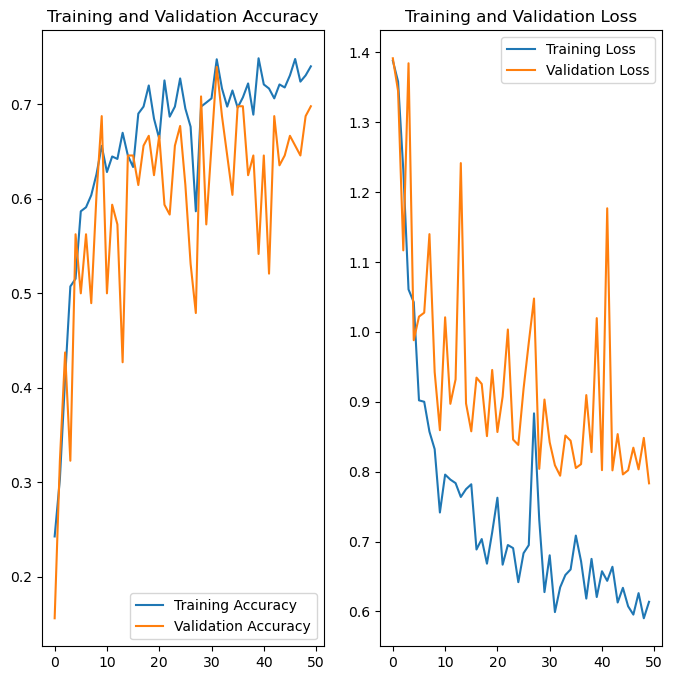

In [41]:
plt.figure(figsize=(8, 8))
plt.subplot(1, 2, 1)
plt.plot(range(EPOCHS), acc, label='Training Accuracy')
plt.plot(range(EPOCHS), val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(range(EPOCHS), loss, label='Training Loss')
plt.plot(range(EPOCHS), val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.show()

# Run prediction on a sample image

first image to predict
actual label: 320
1/1 [==============================] - 0s 303ms/step
predicted label: 320


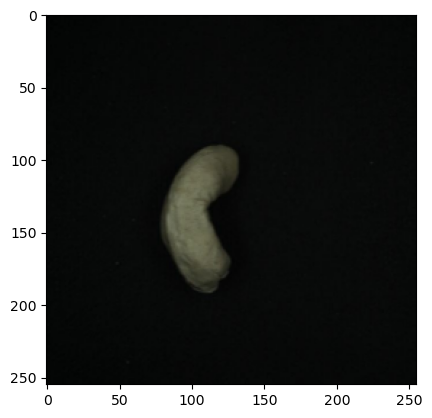

In [44]:
import numpy as np
for images_batch, labels_batch in test_ds.take(1):
    
    first_image = images_batch[0].numpy().astype('uint8')
    first_label = labels_batch[0].numpy()
    
    print("first image to predict")
    plt.imshow(first_image)
    print("actual label:",class_names[first_label])
    
    batch_prediction = model.predict(images_batch)
    print("predicted label:",class_names[np.argmax(batch_prediction[0])])

# Write a function for inference

In [45]:
def predict(model, img):
    img_array = tf.keras.preprocessing.image.img_to_array(images[i].numpy())
    img_array = tf.expand_dims(img_array, 0) # created a batch

    predictions = model.predict(img_array)

    predicted_class = class_names[np.argmax(predictions[0])]
    confidence = round(100 * (np.max(predictions[0])), 2)
    return predicted_class, confidence

# Now run inference on few sample images

1/1 [==============================] - 0s 27ms/step


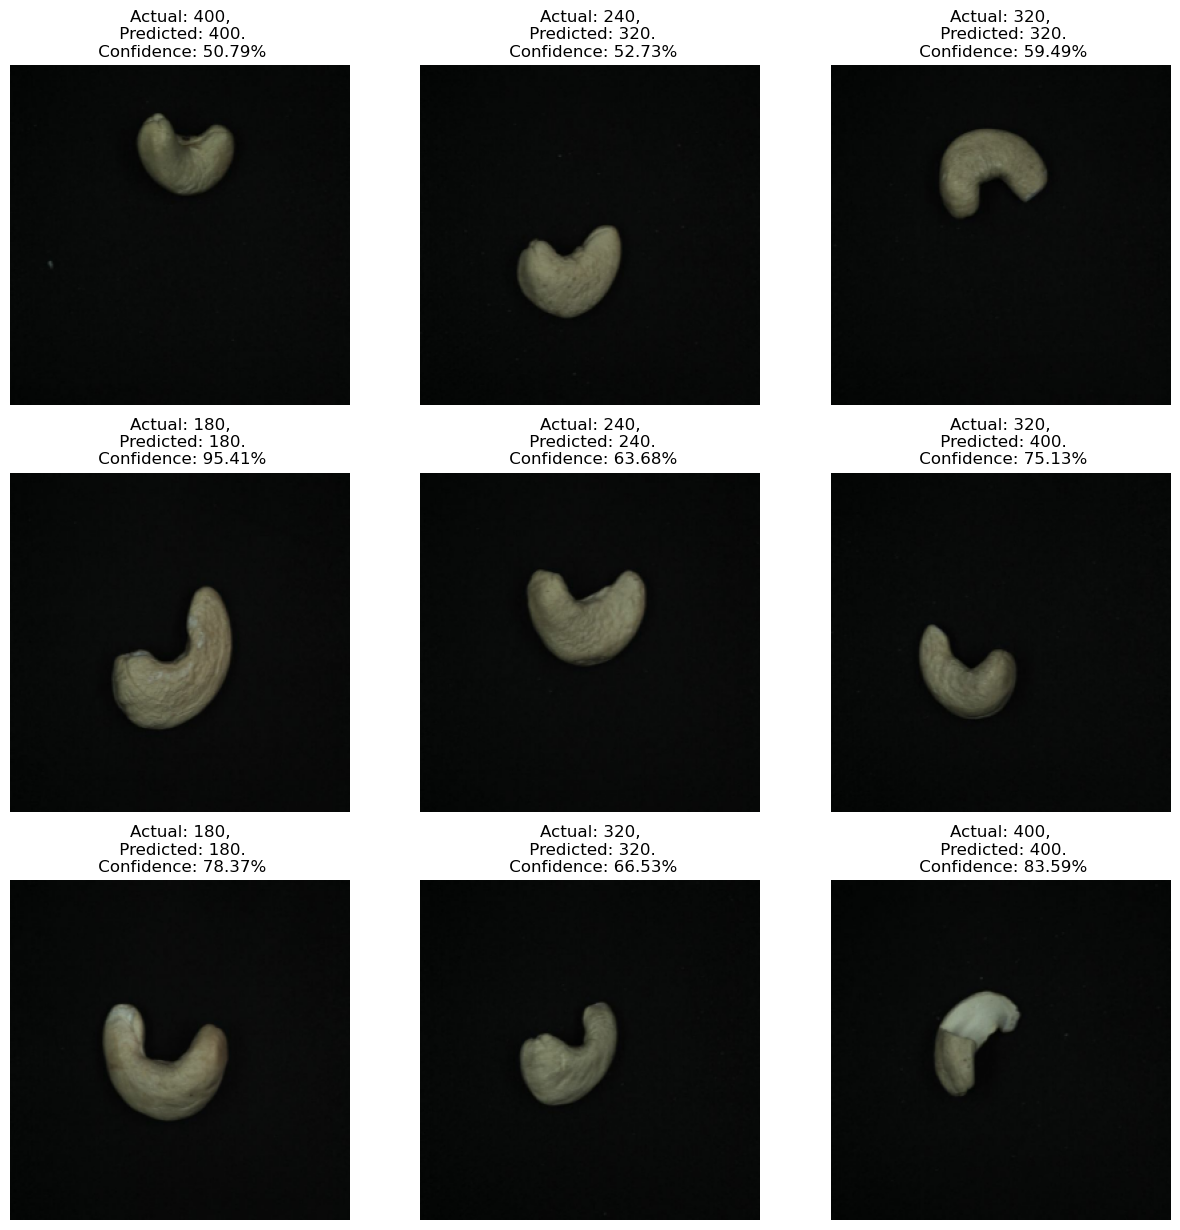

In [47]:
plt.figure(figsize=(15, 15))
for images, labels in test_ds.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        
        predicted_class, confidence = predict(model, images[i].numpy())
        actual_class = class_names[labels[i]] 
        
        plt.title(f"Actual: {actual_class},\n Predicted: {predicted_class}.\n Confidence: {confidence}%")
        
        plt.axis("off")

# Saving the Model
# We append the model to the list of models as a new version

In [49]:
import os
model_version=max([int(i) for i in os.listdir("./models") + [0]])+1
model.save(f"./models/{model_version}")

INFO:tensorflow:Assets written to: ./models/1\assets


INFO:tensorflow:Assets written to: ./models/1\assets


In [51]:
model.save("./cashewclassification.h5")